# Exercise 9 - PCA (Principal Component Analysis)

In the last tutorial we looked at **K-means clustering**, another unsupervised learning method: no target variable `y`, just a set of observations, and the algorithm finds structure in them on its own.

PCA solves a different kind of problem. Instead of grouping observations into clusters, it looks for a small number of new variables - called **principal components** - that capture as much of the original variation in the data as possible. It's a **dimensionality reduction** technique: it lets us compress many correlated features into a handful of components, which is useful for visualizing high-dimensional data, removing redundancy before feeding data into another algorithm, and understanding which features actually drive the variation in a dataset.

We'll use the OECD **Better Life Index** dataset (well-being indicators for 34 countries) to:
1. Reduce 11 well-being indicators per country down to just 2 principal components.
2. Visualize every country in this new 2D space, colored by its life satisfaction score.
3. Interpret what each component represents, in terms of the original indicators.

In [2]:
# pip install scikit-learn plotnine
import pandas as pd
import numpy as np

import matplotlib as mpl

import plotnine as pln
import warnings
from plotnine.exceptions import PlotnineWarning
warnings.filterwarnings("ignore", category=PlotnineWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%config InlineBackend.print_figure_kwargs = {'facecolor': 'white', 'bbox_inches': 'tight'}
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['savefig.transparent'] = False

In [3]:
oecd_df = pd.read_csv('data/oecd_better_life_2015.csv', index_col='Country')
oecd_df

,Household_net_adjusted_disposable_income,Employment_rate,Long_term_unemployment_rate,Quality_of_support_network,Educational_attainment,Student_skills,Air_pollution,Water_quality,Voter_turnout,Life_expectancy,Life_satisfaction,Employees_working_very_long_hours
Country,,,,,,,,,,,,
Australia,31197,72,1.06,93,74,514,13,93,93,82.0,7.4,14.23
Austria,29256,73,1.07,95,82,498,27,95,75,81.1,7.5,8.61
Belgium,27811,62,3.37,91,71,507,21,84,89,80.5,7.1,4.41
Canada,30212,72,0.90,94,89,522,15,90,61,81.0,7.6,3.98
Chile,13762,62,2.01,85,72,439,46,79,88,78.3,6.6,15.42
Czech Republic,17262,67,3.03,87,92,496,16,81,59,78.0,6.7,7.14
Denmark,25172,73,2.11,96,77,500,15,95,88,79.9,7.6,2.06
Estonia,14382,67,5.46,89,89,523,9,80,64,76.3,5.4,3.59
Finland,26904,70,1.65,93,84,529,15,95,69,80.6,7.4,3.70


The dataset contains several OECD well-being indicators for each country, one row per country (`Country` is the country name, so we've set it as the index):

* `Household_net_adjusted_disposable_income` - average household disposable income per person after taxes and transfers, adjusted for purchasing power parity (PPP), in US dollars per capita
* `Employment_rate` - percentage of the working-age population that is employed
* `Long_term_unemployment_rate` - percentage of the labor force that has been unemployed for one year or more
* `Quality_of_support_network` - percentage of people who report having friends or relatives they can rely on in times of need
* `Educational_attainment` - percentage of adults who have completed at least upper-secondary education
* `Student_skills` - average PISA score of 15-year-old students in reading, mathematics, and science
* `Air_pollution` - average exposure to fine particulate matter (PM2.5), in µg/m³
* `Water_quality` - percentage of people who report being satisfied with the quality of their local water
* `Voter_turnout` - percentage of registered voters who participated in elections
* `Life_expectancy` - expected number of years a person is likely to live from birth
* `Employees_working_very_long_hours` - percentage of employees who usually work 50 hours or more per week
* `Life_satisfaction` - a subjective well-being score, on a scale from 0 (worst) to 10 (best)

`Life_satisfaction` won't be used to *fit* PCA - PCA is unsupervised, so it only ever looks at the 11 objective indicators - but we'll use it afterwards as a label to help us interpret what the components found.

In [12]:
print(oecd_df.shape)
print(oecd_df['Life_satisfaction'].sort_values())


(34, 12)
Country
Greece             4.7
Hungary            4.9
Turkey             4.9
Portugal           5.2
Estonia            5.4
Poland             5.7
Slovak Republic    5.9
Italy              6.0
Slovenia           6.0
Korea              6.0
Japan              6.0
Spain              6.2
Chile              6.6
Czech Republic     6.7
France             6.7
Ireland            6.8
United Kingdom     6.9
Germany            7.0
United States      7.0
Luxembourg         7.1
Israel             7.1
Belgium            7.1
New Zealand        7.3
Finland            7.4
Sweden             7.4
Netherlands        7.4
Australia          7.4
Mexico             7.4
Iceland            7.5
Austria            7.5
Canada             7.6
Denmark            7.6
Norway             7.7
Switzerland        7.8
Name: Life_satisfaction, dtype: float64


34 countries, 11 objective well-being indicators each, plus a subjective `Life_satisfaction` score that ranges from about 4.7 (Greece) to 7.8 (Switzerland).

## Why reduce dimensions?

We can easily plot 2 of the 11 indicators against each other, but there's no way to see all 11 at once - a scatter plot only has 2 (or, with color/shape, maybe 4) usable dimensions.

Many of these indicators are also **correlated** with each other. For example, richer countries tend to afford better healthcare and living conditions, so `Household_net_adjusted_disposable_income` and `Life_expectancy` should be related:

correlation: 0.62


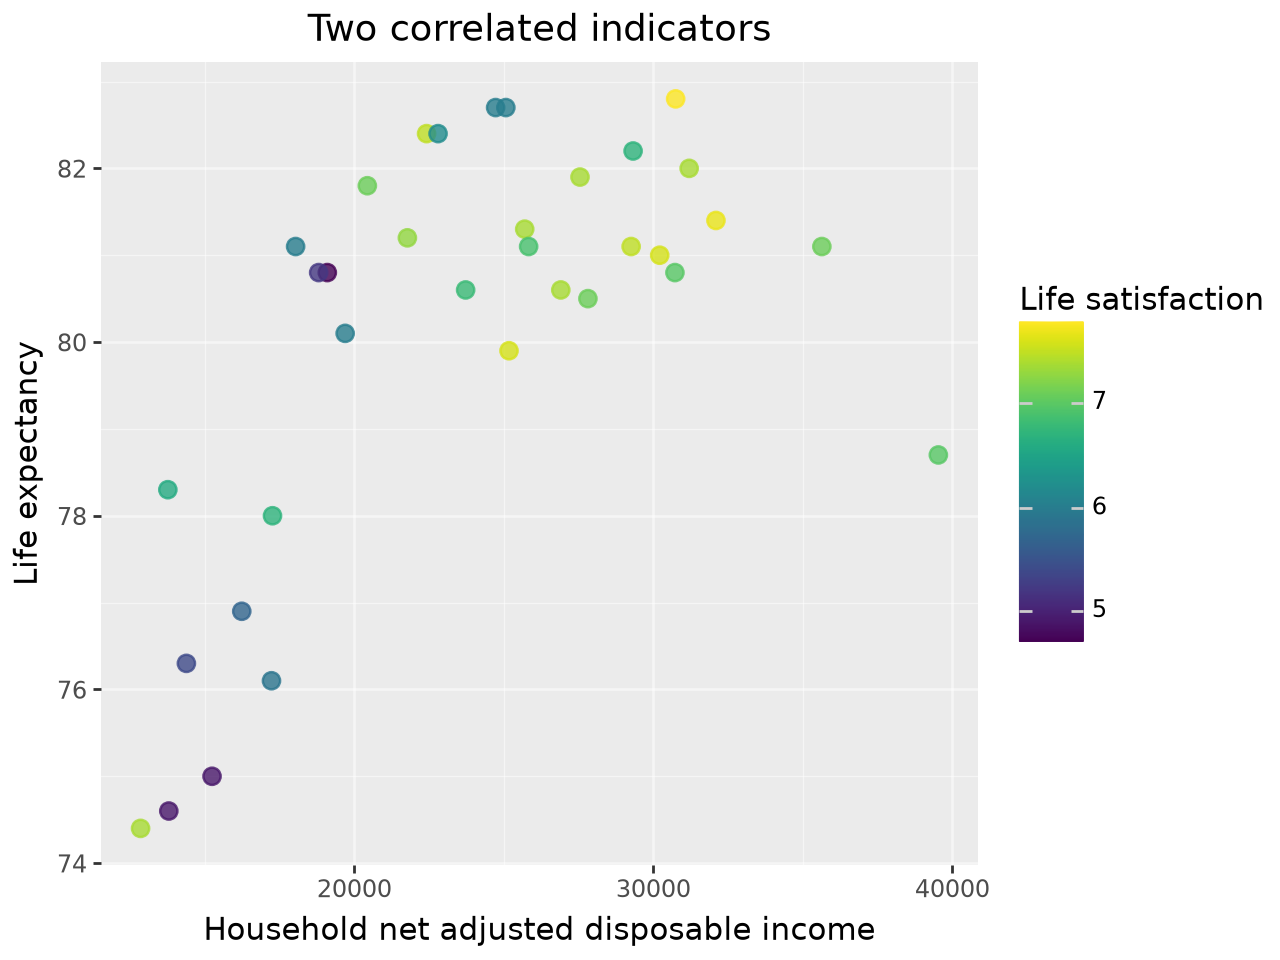

In [5]:
print("correlation:", oecd_df['Household_net_adjusted_disposable_income'].corr(oecd_df['Life_expectancy']).round(2))

(
    pln.ggplot(oecd_df, pln.aes(x='Household_net_adjusted_disposable_income', y='Life_expectancy', color='Life_satisfaction'))
    + pln.geom_point(alpha=0.8, size=3)
    + pln.scale_color_cmap(cmap_name='viridis')
    + pln.labs(x='Household net adjusted disposable income', y='Life expectancy', color='Life satisfaction', title='Two correlated indicators')
)

In [11]:
oecd_df.corr().round(2)

,Household_net_adjusted_disposable_income,Employment_rate,Long_term_unemployment_rate,Quality_of_support_network,Educational_attainment,Student_skills,Air_pollution,Water_quality,Voter_turnout,Life_expectancy,Life_satisfaction,Employees_working_very_long_hours
Household_net_adjusted_disposable_income,1.00,0.54,-0.27,0.52,0.33,0.39,-0.44,0.61,0.25,0.62,0.61,-0.38
Employment_rate,0.54,1.00,-0.63,0.64,0.49,0.42,-0.36,0.83,0.07,0.50,0.78,-0.27
Long_term_unemployment_rate,-0.27,-0.63,1.00,-0.29,-0.22,-0.15,-0.04,-0.35,-0.30,-0.06,-0.62,-0.29
Quality_of_support_network,0.52,0.64,-0.29,1.00,0.42,0.50,-0.48,0.75,0.12,0.45,0.58,-0.48
Educational_attainment,0.33,0.49,-0.22,0.42,1.00,0.54,-0.34,0.44,-0.21,0.17,0.27,-0.45
Student_skills,0.39,0.42,-0.15,0.50,0.54,1.00,-0.36,0.51,-0.14,0.45,0.14,-0.31
Air_pollution,-0.44,-0.36,-0.04,-0.48,-0.34,-0.36,1.00,-0.44,0.03,-0.24,-0.25,0.49
Water_quality,0.61,0.83,-0.35,0.75,0.44,0.51,-0.44,1.00,0.12,0.52,0.64,-0.53
Voter_turnout,0.25,0.07,-0.30,0.12,-0.21,-0.14,0.03,0.12,1.00,0.17,0.28,0.10
Life_expectancy,0.62,0.50,-0.06,0.45,0.17,0.45,-0.24,0.52,0.17,1.00,0.44,-0.31


When two features are highly correlated, they're partly telling us the same thing - this redundancy is "wasted" dimensions. PCA takes advantage of exactly this: it looks for new axes (linear combinations of the original features) that capture as much spread in the data as possible, starting with the direction of *most* variance, then the next direction (orthogonal/uncorrelated to the first) with the *next* most variance, and so on.

## Feature scaling

PCA is based on variance, which is sensitive to the scale of each feature. `Household_net_adjusted_disposable_income` ranges up to ~39,500 while `Air_pollution` ranges only up to ~46 - without scaling, PCA would end up mostly describing the variation in income alone, simply because its raw numbers are so much larger. So, we standardize every feature to mean 0 / standard deviation 1 before fitting PCA:

In [19]:
features = [c for c in oecd_df.columns if c != 'Life_satisfaction']
X = oecd_df[features]

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_scaled

,Household_net_adjusted_disposable_income,Employment_rate,Long_term_unemployment_rate,Quality_of_support_network,Educational_attainment,Student_skills,Air_pollution,Water_quality,Voter_turnout,Life_expectancy,Employees_working_very_long_hours
Country,,,,,,,,,,,
Australia,1.131839,0.763874,-0.716181,0.577125,-0.080661,0.665560,-0.857217,0.870861,1.890446,0.801386,0.483472
Austria,0.839739,0.897749,-0.713138,0.893613,0.429565,0.041311,0.835876,1.077198,0.296847,0.426426,-0.138670
Belgium,0.622282,-0.574874,-0.013070,0.260637,-0.271995,0.392451,0.110264,-0.057653,1.536312,0.176452,-0.603616
Canada,0.983607,0.763874,-0.764882,0.735369,0.876012,0.977684,-0.615347,0.561357,-0.942619,0.384763,-0.651218
Chile,-1.491942,-0.574874,-0.427023,-0.688827,-0.208217,-2.260608,3.133644,-0.573494,1.447779,-0.740118,0.615207
Czech Republic,-0.965229,0.094500,-0.116559,-0.372339,1.067347,-0.036721,-0.494412,-0.367158,-1.119685,-0.865105,-0.301401
Denmark,0.225141,0.897749,-0.396585,1.051857,0.110674,0.119342,-0.615347,1.077198,1.447779,-0.073522,-0.863764
Estonia,-1.398638,0.094500,0.623078,-0.055851,0.876012,1.016700,-1.340958,-0.470326,-0.677019,-1.573364,-0.694391
Finland,0.485788,0.496125,-0.536599,0.577125,0.557121,1.250793,-0.615347,1.077198,-0.234353,0.218114,-0.682214


In [20]:

X_scaled.corr().round(2)

,Household_net_adjusted_disposable_income,Employment_rate,Long_term_unemployment_rate,Quality_of_support_network,Educational_attainment,Student_skills,Air_pollution,Water_quality,Voter_turnout,Life_expectancy,Employees_working_very_long_hours
Household_net_adjusted_disposable_income,1.00,0.54,-0.27,0.52,0.33,0.39,-0.44,0.61,0.25,0.62,-0.38
Employment_rate,0.54,1.00,-0.63,0.64,0.49,0.42,-0.36,0.83,0.07,0.50,-0.27
Long_term_unemployment_rate,-0.27,-0.63,1.00,-0.29,-0.22,-0.15,-0.04,-0.35,-0.30,-0.06,-0.29
Quality_of_support_network,0.52,0.64,-0.29,1.00,0.42,0.50,-0.48,0.75,0.12,0.45,-0.48
Educational_attainment,0.33,0.49,-0.22,0.42,1.00,0.54,-0.34,0.44,-0.21,0.17,-0.45
Student_skills,0.39,0.42,-0.15,0.50,0.54,1.00,-0.36,0.51,-0.14,0.45,-0.31
Air_pollution,-0.44,-0.36,-0.04,-0.48,-0.34,-0.36,1.00,-0.44,0.03,-0.24,0.49
Water_quality,0.61,0.83,-0.35,0.75,0.44,0.51,-0.44,1.00,0.12,0.52,-0.53
Voter_turnout,0.25,0.07,-0.30,0.12,-0.21,-0.14,0.03,0.12,1.00,0.17,0.10
Life_expectancy,0.62,0.50,-0.06,0.45,0.17,0.45,-0.24,0.52,0.17,1.00,-0.31


## How PCA works

Given the scaled features, PCA finds the new axes - the **principal components** - as follows:

1. Compute the **covariance matrix** of the (scaled) features, which captures how every pair of features varies together.
2. Find the covariance matrix's **eigenvectors** and **eigenvalues**. Each eigenvector is a direction (a linear combination of the original features); its eigenvalue tells us how much variance the data has along that direction.
3. Sort the eigenvectors by eigenvalue, largest first. The first principal component (PC1) is the eigenvector with the largest eigenvalue - the single direction along which the data varies the most. PC2 is the direction with the next-largest eigenvalue, *constrained to be orthogonal (uncorrelated) to PC1*. And so on for PC3, PC4, ...

You don't need to compute eigenvectors by hand - `sklearn`'s `PCA` does all of this for us. With 11 input features, PCA can produce up to 11 components (it's just a rotation of the original axes, so no information is lost if we keep all of them) - the point is that the first few components usually capture most of the variance, so we can discard the rest with little loss.

Let's fit PCA with all 11 components first, to see how much variance each one explains:

In [21]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
for i, ratio in enumerate(explained, start=1):
    print(f"PC{i}: {ratio:.3f}")

PC1: 0.441
PC2: 0.158
PC3: 0.109
PC4: 0.074
PC5: 0.053
PC6: 0.051
PC7: 0.044
PC8: 0.027
PC9: 0.024
PC10: 0.014
PC11: 0.005


In [22]:
explained.sum()

np.float64(1.0)

This is easier to read as a **scree plot** - the variance explained by each individual component - together with the **cumulative** variance explained as we keep adding components:

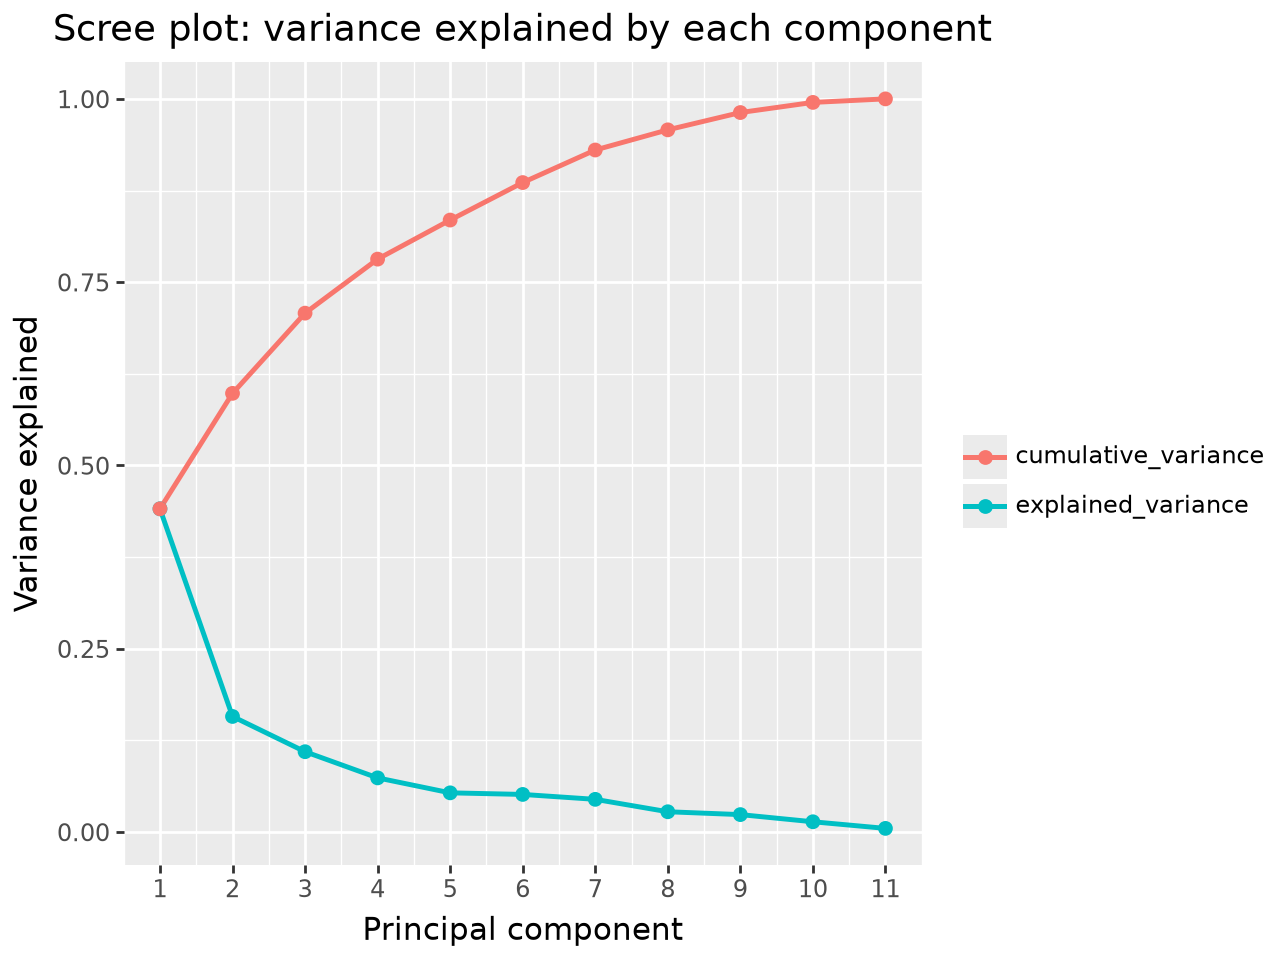

In [7]:
scree_df = pd.DataFrame({
    'component': range(1, len(explained) + 1),
    'explained_variance': explained,
    'cumulative_variance': np.cumsum(explained),
})

scree_long = scree_df.melt(id_vars='component', value_vars=['explained_variance', 'cumulative_variance'],
                            var_name='type', value_name='variance')

(
    pln.ggplot(scree_long, pln.aes(x='component', y='variance', color='type'))
    + pln.geom_line(size=1)
    + pln.geom_point(size=2)
    + pln.scale_x_continuous(breaks=list(scree_df['component']))
    + pln.labs(x='Principal component', y='Variance explained', color='',
               title='Scree plot: variance explained by each component')
)

There's a fairly clear "elbow" here - PC1 alone explains about 44% of the variance, roughly three times as much as PC2 (16%), and each component after that adds a modest amount. If our goal were to preprocess this data as input to another model, we might keep enough components to reach, say, 80-90% cumulative variance (around 5-6 components here). Since our goal is *visualization*, we'll keep it simple and just use the first 2 components - together they explain about **60%** of the total variance. That's a real loss of information (40% of the variance is left behind), but the payoff is a **dimensionality reduction from 11 down to just 2 numbers per country** - something we can actually plot and reason about, which we couldn't do with 11 original indicators. And it's the best possible 2D summary of this 11-dimensional data: no other pair of directions could capture more variance.

## How PCA works in practice
Before we see how PCA performs dimensionality reduction in practice, let’s first understand how it is calculated mathematically.
As we discussed, PCA is based on the eigenvalues and eigenvectors of the correlation matrix. After fitting a PCA model using the fit() method, we can examine the eigenvectors that were calculated.
The projection of each observation onto the (i)-th eigenvector is called the (i)-th principal component. It is calculated as a linear combination of the original variable values for that observation.
The elements of the (i)-th eigenvector determine how much each original variable contributes to the corresponding principal component. In other words, they act as weights in the linear combination and are commonly referred to as loadings
Thus, PCA creates new variables - the principal components - by combining the original variables according to the directions defined by the eigenvectors.



In [33]:
pca = PCA()
X_pca_fit = pca.fit(X_scaled)
X_pca_fit.components_

array([[ 0.34226871,  0.37917317, -0.16412352,  0.376118  ,  0.28338882,
         0.30525454, -0.27068968,  0.40631799,  0.04347875,  0.2934961 ,
        -0.26606658],
       [-0.10656413, -0.2400843 ,  0.59482099, -0.01325991,  0.1993391 ,
         0.15548674, -0.26728259, -0.06748179, -0.4853693 , -0.05519307,
        -0.44551113],
       [ 0.29295908, -0.22490962,  0.385163  ,  0.0331484 , -0.45283668,
        -0.21540658, -0.15050043,  0.00265276,  0.50815208,  0.36390343,
        -0.2222129 ],
       [ 0.11443665, -0.04419738,  0.13279226, -0.16045458, -0.08804062,
         0.44974922,  0.44135039, -0.08924141, -0.26704344,  0.6251026 ,
         0.2583142 ],
       [ 0.19463805, -0.29764601, -0.07496155, -0.15173766,  0.21265115,
         0.48855522, -0.48245711, -0.35506861,  0.29851039, -0.11442097,
         0.31612248],
       [-0.03538054, -0.20441803,  0.05293113, -0.0186015 ,  0.52547711,
         0.10736577,  0.55562638, -0.04905603,  0.46666351, -0.07746274,
        -0.362

Note that the eigenvectors stored in the `components_` attribute are represented as **rows rather than columns**. Therefore, before multiplying them by the matrix of variables, we first transpose them.
We use **matrix multiplication** because it provides a convenient way to multiply the variable values of every observation by each eigenvector and calculate the corresponding principal component scores efficiently.

In [34]:
np.dot(X_scaled, X_pca_fit.components_.T)

array([[ 1.96659828e+00, -1.65708859e+00,  1.07237315e+00,
        -1.20551417e-01,  9.96872916e-01, -8.98140778e-02,
        -2.41577182e-01, -2.40743333e-01, -1.88052720e-01,
         4.08736321e-01,  6.67927238e-02],
       [ 1.60168767e+00, -1.05095096e+00, -1.90483686e-01,
         2.23347387e-01, -8.64143250e-01,  5.29891978e-01,
         9.40074473e-02,  5.16276328e-01,  7.06023692e-02,
         2.97826891e-01,  4.87315107e-03],
       [ 3.63817200e-01, -4.44805041e-01,  1.31611175e+00,
        -1.48559053e-01,  6.02425584e-01,  9.75220060e-01,
        -3.38378723e-01,  3.33725321e-01, -2.56232007e-01,
        -3.07781380e-01, -1.95047239e-02],
       [ 2.21498084e+00,  4.26707156e-01, -8.61333013e-01,
         2.24162074e-01,  1.40061690e-01, -2.83019598e-01,
         3.80260107e-01,  4.84495067e-01, -2.48955161e-02,
        -4.37535927e-01, -5.49665995e-02],
       [-3.06591101e+00, -2.07567097e+00, -5.73346312e-02,
        -3.46018419e-01, -1.72833388e+00,  2.08772528e+00,
  

Note that the **sum of the squared loadings** for each principal component is equal to **1**. This is because each eigenvector is normalized to have unit length.

In [50]:
((X_pca_fit.components_)**2).sum(axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Now, let’s see how all these calculations can be performed much more easily by using the `fit_transform()` method instead of calling `fit()` and calculating the principal component scores manually.

In [52]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by PC1 + PC2:", round(pca.explained_variance_ratio_.sum(), 3))

pc_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=oecd_df.index)
pc_df['Life_satisfaction'] = oecd_df['Life_satisfaction'].values
pc_df

Variance explained by PC1 + PC2: 0.598


,PC1,PC2,Life_satisfaction
Country,,,
Australia,1.96660,-1.65709,7.40000
Austria,1.60169,-1.05095,7.50000
Belgium,0.36382,-0.44481,7.10000
Canada,2.21498,0.42671,7.60000
Chile,-3.06591,-2.07567,6.60000
Czech Republic,-0.36193,1.10524,6.70000
Denmark,1.82141,-0.67081,7.60000
Estonia,-0.14212,1.94538,5.40000
Finland,2.03881,0.30525,7.40000


Each country is now described by just 2 numbers instead of 11. Let's plot every country in this new 2D space, colored by its life satisfaction score, to see whether these components pick up any signal related to well-being (remember: PCA never saw `Life_satisfaction` while fitting):

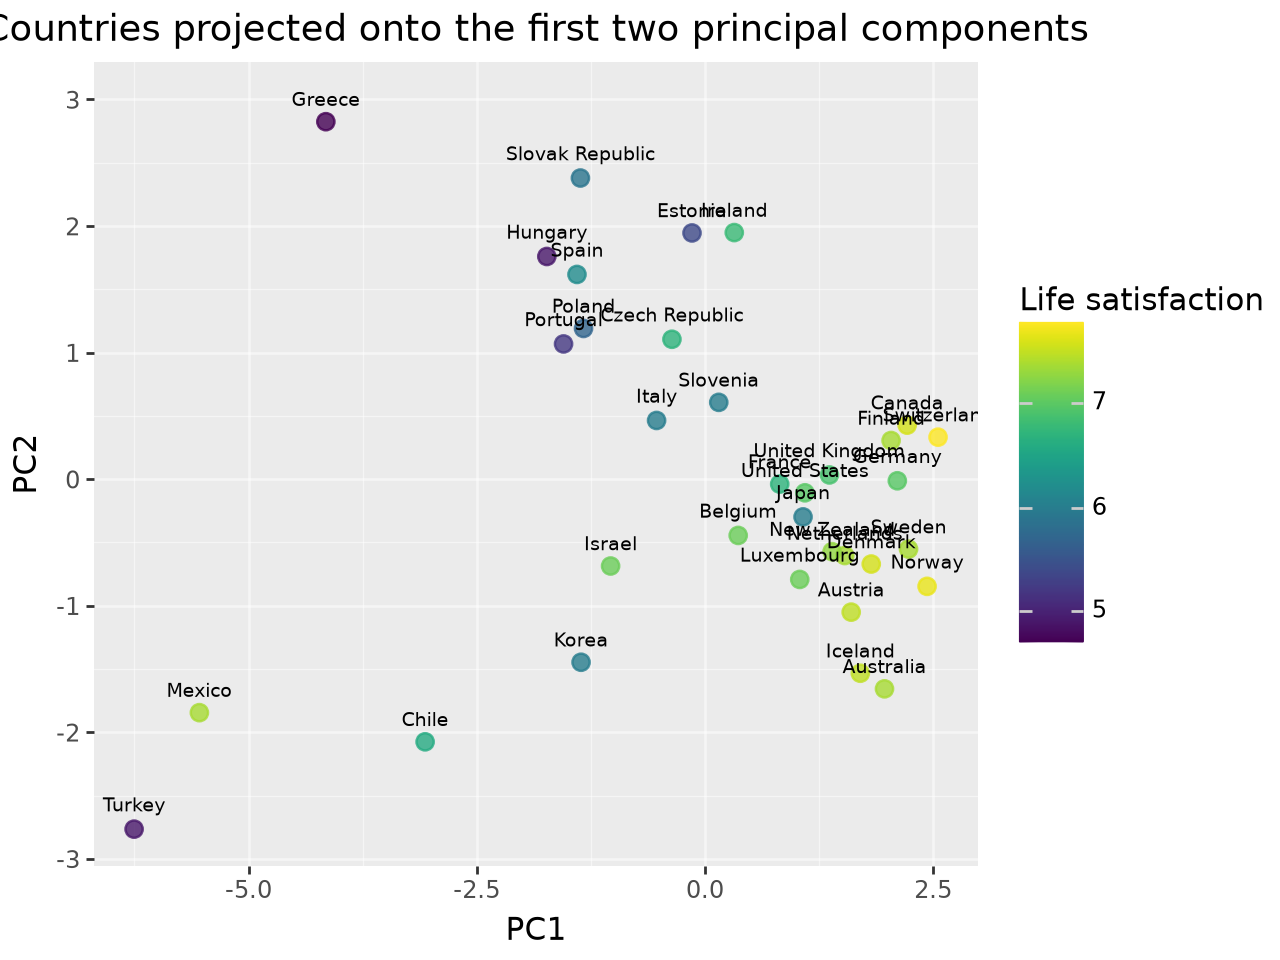

In [24]:
(
    pln.ggplot(pc_df.reset_index(), pln.aes(x='PC1', y='PC2', color='Life_satisfaction', label='Country'))
    + pln.geom_point(alpha=0.8, size=3)
    + pln.geom_text(nudge_y=0.18, size=7, color='black')
    + pln.scale_color_cmap(cmap_name='viridis')
    + pln.labs(x='PC1', y='PC2', color='Life satisfaction', title='Countries projected onto the first two principal components')
)

There's a clear gradient here: brighter (higher life-satisfaction) countries like Switzerland, Norway, and Denmark sit toward the positive end of PC1, while darker (lower life-satisfaction) countries like Turkey, Hungary, and Greece sit toward the negative end. Numerically, `PC1` correlates with life satisfaction at about **0.67** (fairly strong), while `PC2` correlates at about **-0.45** (moderate) - so, unlike in some datasets, the single biggest source of variation PCA found (PC1) turns out to align closely with subjective well-being, even though PCA never saw `Life_satisfaction` while fitting. One clear exception is Mexico: it scores among the lowest on PC1 (similar to Turkey and Greece), yet reports one of the highest life satisfaction scores (7.4) - a reminder that subjective well-being doesn't always track objective indicators.

## Interpreting the components

A principal component is a weighted combination of the original (scaled) features. Those weights are called **loadings**, and they tell us what each component actually represents. They're stored in `pca.components_` - one row per component, one column per original feature:

In [56]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1_loadings', 'PC2_loadings'], index=features)
loadings

,PC1_loadings,PC2_loadings
Household_net_adjusted_disposable_income,0.34227,-0.10656
Employment_rate,0.37917,-0.24008
Long_term_unemployment_rate,-0.16412,0.59482
Quality_of_support_network,0.37612,-0.01326
Educational_attainment,0.28339,0.19934
Student_skills,0.30525,0.15549
Air_pollution,-0.27069,-0.26728
Water_quality,0.40632,-0.06748
Voter_turnout,0.04348,-0.48537
Life_expectancy,0.29350,-0.05519


In [58]:
loadings.sort_values('PC1_loadings', ascending=False)

,PC1_loadings,PC2_loadings
Water_quality,0.40632,-0.06748
Employment_rate,0.37917,-0.24008
Quality_of_support_network,0.37612,-0.01326
Household_net_adjusted_disposable_income,0.34227,-0.10656
Student_skills,0.30525,0.15549
Life_expectancy,0.29350,-0.05519
Educational_attainment,0.28339,0.19934
Voter_turnout,0.04348,-0.48537
Long_term_unemployment_rate,-0.16412,0.59482
Employees_working_very_long_hours,-0.26607,-0.44551


**PC1** has positive loadings for nearly every indicator - `Water_quality`, `Employment_rate`, `Quality_of_support_network` and `Household_net_adjusted_disposable_income` are the strongest - and negative loadings only for `Air_pollution` and `Employees_working_very_long_hours`. So PC1 is essentially a general **overall prosperity / well-being** axis: countries high on PC1 (e.g. Switzerland, Norway, Canada) tend to be richer, more employed, better supported, less polluted, and less overworked all at once; countries low on PC1 (e.g. Turkey, Mexico, Greece) tend to score worse across most of these indicators simultaneously.

**PC2** has a large positive loading for `Long_term_unemployment_rate`, and clearly negative loadings for `Voter_turnout` and `Employees_working_very_long_hours`. So PC2 is mainly a **long-term unemployment vs. work/civic engagement** axis: countries high on PC2 (e.g. Greece, Slovak Republic, Spain) combine high long-term unemployment with lower voter turnout and fewer long-hour workers; countries low on PC2 (e.g. Turkey, Mexico, Korea) combine very low long-term unemployment with a culture of long working hours instead. Since PC2 correlates negatively with life satisfaction, this lines up with a well-known finding: long-term unemployment weighs on well-being even in countries that otherwise look prosperous.

Let's visualize both sets of loadings side by side:

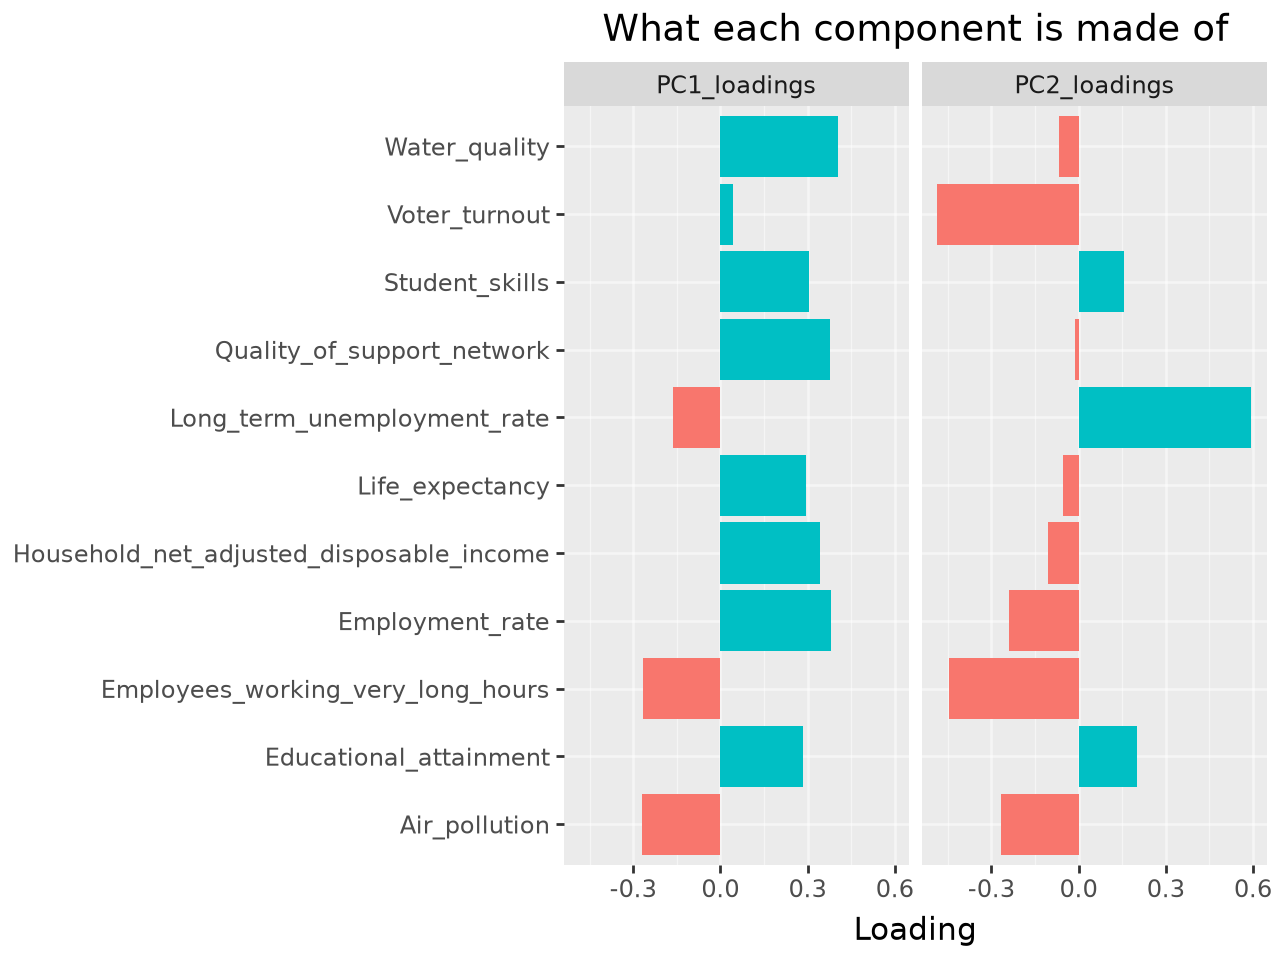

In [60]:
loadings_long = loadings.reset_index().rename(columns={'index': 'feature'}).melt(
    id_vars='feature', value_vars=['PC1_loadings', 'PC2_loadings'], var_name='component', value_name='loading')

(
    pln.ggplot(loadings_long, pln.aes(x='feature', y='loading', fill='loading > 0'))
    + pln.geom_col(show_legend=False)
    + pln.facet_wrap('component')
    + pln.coord_flip()
    + pln.labs(x='', y='Loading', title='What each component is made of')
)

## Biplot: scores and loadings together

We can combine the two plots above into a single **biplot**: the countries plotted by their PC1/PC2 scores (as before), with an arrow for each original feature showing the direction it points in this new space. A long arrow means that feature has a strong loading (it matters a lot to at least one component); arrows pointing in a similar direction represent correlated features; arrows pointing in opposite directions represent inversely related features:

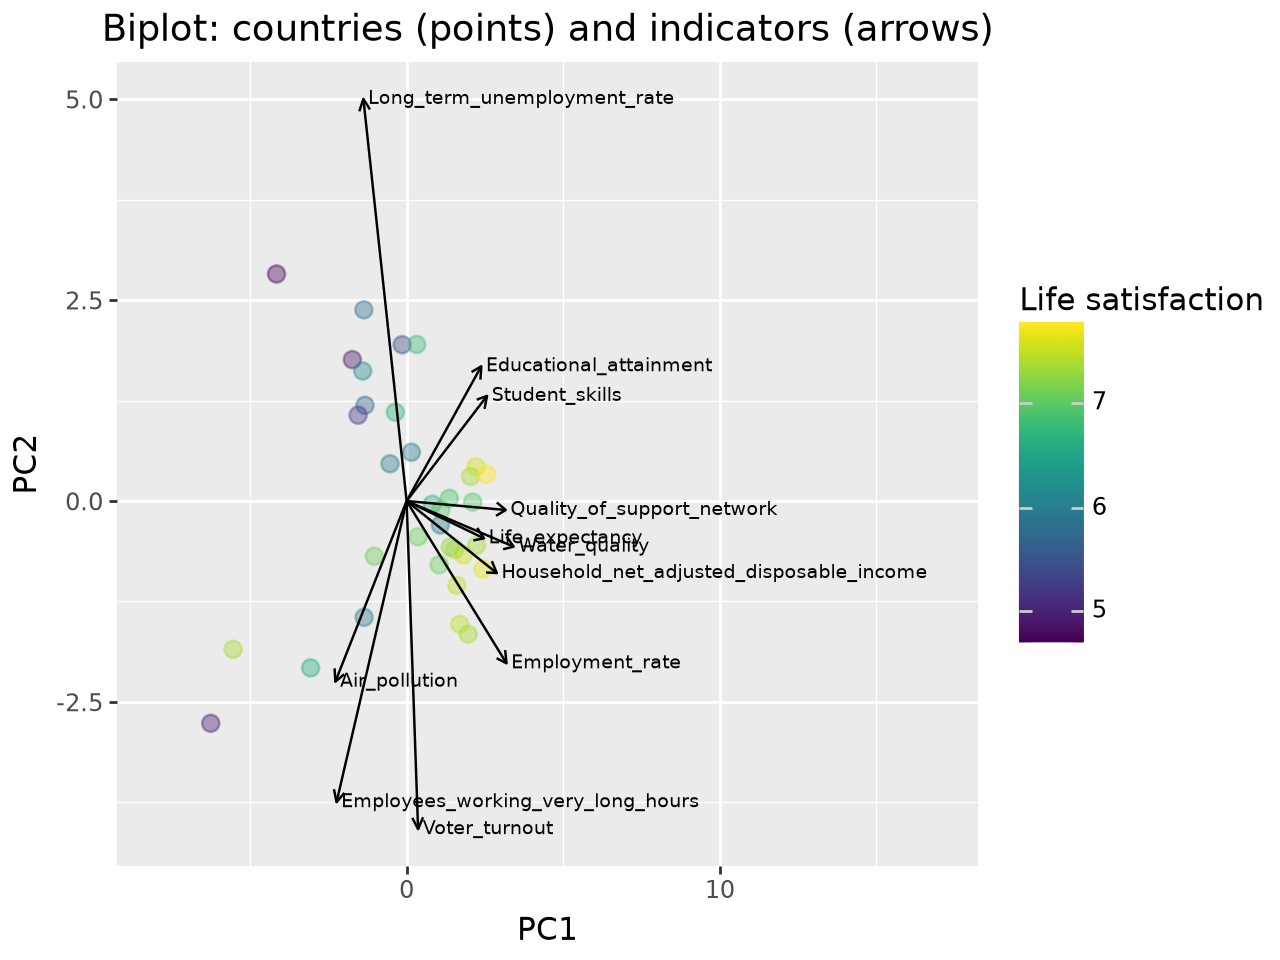

In [12]:
# stretch the (tiny) loading values so the arrows are visible on the same scale as the (larger) PC scores
arrow_scale = np.abs(X_pca).max() / np.abs(loadings.values).max() * 0.8

arrows_df = loadings.reset_index().rename(columns={'index': 'feature'})
arrows_df['x'] = 0
arrows_df['y'] = 0
arrows_df['xend'] = arrows_df['PC1'] * arrow_scale
arrows_df['yend'] = arrows_df['PC2'] * arrow_scale

(
    pln.ggplot()
    + pln.geom_point(pc_df, pln.aes(x='PC1', y='PC2', color='Life_satisfaction'), alpha=0.4, size=3)
    + pln.scale_color_cmap(cmap_name='viridis')
    + pln.geom_segment(arrows_df, pln.aes(x='x', y='y', xend='xend', yend='yend'),
                        arrow=pln.arrow(length=0.08), color='black')
    + pln.geom_text(arrows_df, pln.aes(x='xend', y='yend', label='feature'),
                     color='black', size=7, ha='left', nudge_x=0.15)
    + pln.coord_cartesian(xlim=(-8, 17))
    + pln.labs(x='PC1', y='PC2', color='Life satisfaction', title='Biplot: countries (points) and indicators (arrows)')
)

## Summary

In this tutorial we:

* Learned what **PCA** does: find new axes, ordered so that PC1 captures the most variance, PC2 the next most (while staying orthogonal/uncorrelated to PC1), and so on.
* Saw why **feature scaling** matters for PCA, for the same reason it mattered for K-means: it's based on variance, so unscaled features with large numeric ranges would dominate the result.
* Used **explained variance ratio** and a **scree plot** to see how much information each component captures, and how many components we'd need to capture most of the variance.
* Reduced 11 correlated well-being indicators down to 2 principal components, and plotted every country in this new 2D space (2 axis) - something impossible to do directly with all 11 original indicators.
* Interpreted the components via their **loadings**: PC1 turned out to represent overall prosperity/well-being, and PC2 a long-term-unemployment-vs-engagement axis - both of which correlated with life satisfaction, even though PCA never saw `Life_satisfaction` during fitting.
* Combined scores and loadings into a single **biplot** to see both the countries and the original indicators in the same 2D space at once.

## Optional exercises

1. Fit `PCA(n_components=3)` (or more) and make a scatter plot of PC1 vs. PC3 (or PC2 vs. PC3). Does either pair separate life satisfaction any better than PC1 vs. PC2?
2. Skip the `StandardScaler` step and redo the plots. How much does the biplot change, and which features end up dominating PC1?
3. Try `KMeans` on the 2D PCA-reduced data (`X_pca`) instead of the raw scaled features, and color the biplot by the resulting cluster labels instead of `Life_satisfaction`. Do the clusters line up with any visible structure in the biplot, or with geography (e.g. Nordic vs. Southern/Eastern Europe)?
4. Look up how many components are needed to reach 90% cumulative explained variance using `scree_df`. Refit PCA with exactly that many components.
5. `pca.components_` and `pca.explained_variance_ratio_` describe the *training* data. Try transforming a single new (made-up) country's indicators with `pca.transform(...)` (remember to scale it with the same `scaler` first) and see where it lands on the biplot.